## Unmodified thimbles

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def thimble_plot(action=None, drift=None, crit_points=None, flow_equation=None, 
                sigma_abs=1, sigma_phase=np.pi/4,interaction_abs=1, interaction_phase=0,
                epsilon = 0.001, t_span = (0, 10),t_points=1000, 
                x_range = (-3, 3), y_range = (-3, 3),
                ):
    
    import numpy as np
    sigma = sigma_abs*np.exp(1j*sigma_phase)
    interaction = interaction_abs*np.exp(1j*interaction_phase)

    if action==None:
        def action(z, sigma, interaction):
            """Action S(z) = 1/2 * sigma * z^2 + interaction / 4 * z^4"""

            return 1/2 * sigma * z**2 + interaction / 4 * z**4
    if drift==None:
        def drift(z, sigma,interaction):
            """Derivative of the action with respect to z."""
            return sigma * z + interaction * z**3
        
    if crit_points==None:
        cp0 = -np.sqrt(-sigma / interaction)
        cp1 = 0
        cp2 = +np.sqrt(-sigma / interaction)
        crit_points = np.array([cp0, cp1, cp2])

    if flow_equation==None:
        def flow_equation(t, z, sigma, interaction, factor):
            """The flow equation dz/dt = conjugate(S'(z))"""
            dz_dt = factor*np.conj(drift(z, sigma, interaction))
            return dz_dt

    t_eval = np.linspace(t_span[0], t_span[1], t_points)

    # Loop through each sigma value and corresponding subplot
    fig, ax = plt.subplots(1, figsize=(7, 7), sharex= True, sharey = True)
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
        
        # Plot the flow of Lefschetz Thimbles
    for cp in crit_points:
        for perturb in epsilon*np.exp(1j*np.linspace(0, 2*np.pi, 8, endpoint=False)):
            z0 = cp + perturb

            factor = +1
            solution = solve_ivp(flow_equation, t_span, [z0], args=(sigma, interaction, factor), t_eval=t_eval, method="RK45")
            z_values = solution.y[0]
            ax.plot(z_values.real, z_values.imag, color='black')

            factor = -1
            solution = solve_ivp(flow_equation, t_span, [z0], args=(sigma, interaction, factor), t_eval=t_eval, method="RK45")
            z_values = solution.y[0]
            ax.plot(z_values.real, z_values.imag, color='black', ls='--')
        
    # Scatter plot the critical points
    ax.scatter(crit_points.real, crit_points.imag, color='red', zorder=5, label="critical points")
    
    # Create the vector field of the action
    x = np.linspace(*x_range, 25)
    y = np.linspace(*y_range, 25)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    S_values = -1*drift(Z, sigma=sigma, interaction=interaction)
    U = np.real(S_values)
    V = np.imag(S_values)
    mags = np.abs(S_values)
    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=40, alpha=0.9)

    # Add background heatmap for drift values
    x = np.linspace(*x_range, 200)
    y = np.linspace(*y_range, 200)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    S_values = drift(Z, sigma=sigma, interaction=interaction)
    mags = (np.abs(S_values))
    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    # Set plot details for each subplot
    fig.suptitle(f'σ = {np.round(sigma, decimals=2)}', fontsize=14)
    ax.set_xlabel('Re(z)', fontsize=12)
    ax.set_ylabel('Im(z)', fontsize=12)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)# S_derivative_real
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlim(*(val * 1.0001 for val in x_range))
    ax.set_ylim(*(val * 1.0001 for val in y_range))

    from matplotlib.lines import Line2D

    handles, labels = plt.gca().get_legend_handles_labels()

    line_stable = Line2D([0], [0], label=r'$\mathcal{J}$', ls='-', color='black')
    line_unstable = Line2D([0], [0], label=r'$\mathcal{K}$', ls = '--', color='black')

    # add manual symbols to auto legend
    handles.extend([line_unstable, line_stable])

    ax.legend(handles=handles, bbox_to_anchor=(0, 1.01, 1, 0.2), fontsize = 10, loc="lower left",mode="expand", borderaxespad=0, ncol=4, handletextpad=0.5)
    fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9, hspace=0.0, wspace=0.0)

### Critical points
The unmodified drift reads
$$
\partial_{z}S = \sigma z+\lambda z^3
$$
critical points are given by $\partial_{z}S = 0$
$$
z_{0} = 0\qquad z^\pm = \pm \sqrt{ -\frac{\sigma}{\lambda} } = \sqrt{ \frac{\sigma_{r}}{\lambda_{r}}}e^{i(\sigma_{\phi}-\lambda_{\phi}\pm \pi)/2}
$$
The curvature is
$$
\partial_{z}^2S = \sigma+3\lambda z^2
$$
The critical points can be classified into attractive/repulsive.
$$
z_{0}: \qquad \mathrm{Re}(\partial_{z}^2S) = \sigma_{r}\cos(\sigma_{\phi})
$$
$$
z^\pm: \qquad \mathrm{Re}(\partial_{z}^2S) = \sigma_{r}\cos(\sigma_{\phi})+3\sigma_{r}\cos(\sigma_{\phi}-\lambda_{\phi}\pm \pi)
$$

Concerning the drift $\propto -\partial_{z}S$ $z_{0}$ is attractive for $\sigma_{\phi} \in \left( \frac{\pi}{2}, \frac{3\pi}{2} \right)$.
$z^{\pm}$ will change it's curvature at 
$$
\cos(\sigma_{\phi})=3\cos(\sigma_{\phi}-\lambda_{\phi})
$$
For $\lambda_{\phi} \in \{ 0, \pi \}$ we find $\sigma_{\phi} \in \left\{ \frac{\pi}{2}, \frac{3\pi}{2}  \right\}$ 
For $\lambda_{\phi} \in (0, 2\pi)$ the $\sigma_{\phi}$ has to fulfill 
$$
\sigma_{\phi} = \frac{3\sin(\lambda_{\phi})}{3\cos(\lambda_{\phi})-1}
$$


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_11677/1473015571.py:71: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=40, alpha=0.9)


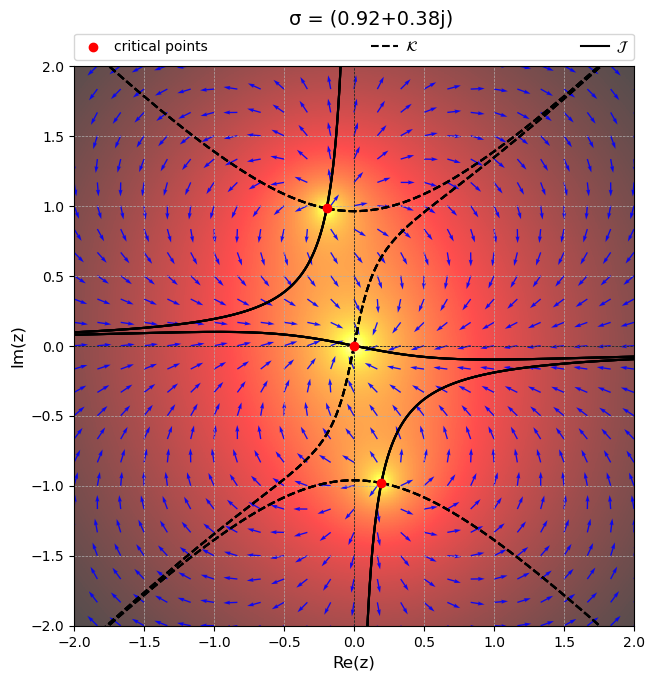

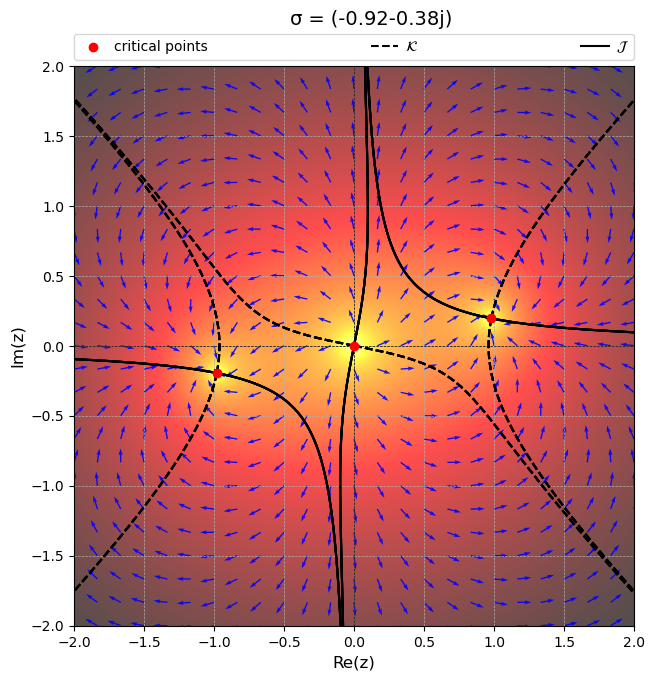

In [2]:
thimble_plot(sigma_phase=np.pi/8, sigma_abs = 1, x_range=(-2, 2), y_range=(-2, 2))
thimble_plot(sigma_phase=np.pi+np.pi/8, sigma_abs = 1, x_range=(-2, 2), y_range=(-2, 2))

We want to artificially introduce zeros in the density by a additive modification of the action. 
$$
S \to \tilde{S} = \frac{\sigma}{2}z^2+\frac{\lambda}{4}z^4+\psi(z)\qquad \rho \to \tilde{\rho} = \rho + R(z)
$$
forcing $\tilde{\rho} = \tilde{S}$ gives
$$
\psi(z) = -\ln(1+R(z)e^{S})
$$

As an example, we want to generate a zero in $\tilde{\rho}$ at a finite $z = z_{0}$. 
This is achieved by setting $R(z) = -\rho(z_{0})$ resulting in 
$$
\psi(z) = -\ln\left( 1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right) \right)
$$
The drift is calculated
$$
\partial_{z}\tilde{S} = \partial_{z}S+\partial_{z}\psi= \partial_{z}S+\frac{\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}{1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}\partial_{z}S= \partial_{z}S\, \left[ 1+\frac{\exp{\{S(z)-S(z_{0})\}}}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$
Further simplifying
$$
\partial_{z}\tilde{S} = \partial_{z}S \, \left[ \frac{1}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$

Modify action $S = \frac{1}{2} \sigma z^2+\frac{1}{4}\lambda z^4$ by some function $\psi (z) = \psi_{r}e^{i\psi_{\phi}}$ with $\psi_{r} \in \mathbb{R}^+, \psi_{\phi} \in [0, 2\pi)$
$$\tilde{S} = \frac{1}{2} \sigma_{r} e^{i\sigma_{\phi}} z_{r}^2e^{2i r_{\phi}}+\frac{1}{4}\lambda_{r}e^{i\lambda_{\phi}} z_{r}^4e^{4iz_{\phi}} +\psi_{r}e^{i\psi_{\phi}}$$

Choosing the modification with the condition
$$\psi_{r}(z_{r}) = \frac{1}{|\sin(\psi_{\phi}(z_{r})+ z_\phi^0)|} \tag{4}$$

leaves the general thimble structure (stable thimbles grow along $\frac{k\pi}{2}$, unstable thimbles grow along $\frac{2k+1}{2}\pi$) unchanged.  
We want to check the validity of this statement

In [64]:
from sympy import symbols, diff, Function, re, im, sqrt, exp, I
import sympy as sp
sigma_r, lamb_r = symbols('sigma_r, lambda_r')
sigma_phi, lamb_phi = symbols('sigma_phi, lambda_phi')
sigma, lamb = sigma_r*exp(I*sigma_phi), lamb_r*exp(I*lamb_phi)
z_phi, z_r = symbols('z_phi, z_r')
z = symbols('z')
action = sigma/2*z**2 + lamb/4*z**4
drift = sigma*z + lamb*z**3
curv = sigma + 3*lamb*z**2
action = action.subs({z : z_r*exp(I*z_phi)})
drift = drift.subs({z : z_r*exp(I*z_phi)})
# curv = curv.subs({z : z_r*exp(I*z_phi)})

In [68]:
crit = [0, sqrt(-sigma/lamb), -sqrt(-sigma/lamb)]
re(curv.subs({z:crit[0]}))

re(sigma_r*exp(I*sigma_phi))

In [30]:
# Modification
z_phi_0 = symbols('z_phi^0')
psi_phi = Function(symbols('psi_phi'))(symbols('z'))
psi_r = 1/sp.asin(psi_phi+z_phi_0)
psi = psi_r*exp(I*psi_phi)
diff(psi, symbols('z')).simplify()

I*exp(I*psi_phi(z))*Derivative(psi_phi(z), z)/asin(z_phi^0 + psi_phi(z)) - exp(I*psi_phi(z))*Derivative(psi_phi(z), z)/(sqrt(1 - (z_phi^0 + psi_phi(z))**2)*asin(z_phi^0 + psi_phi(z))**2)

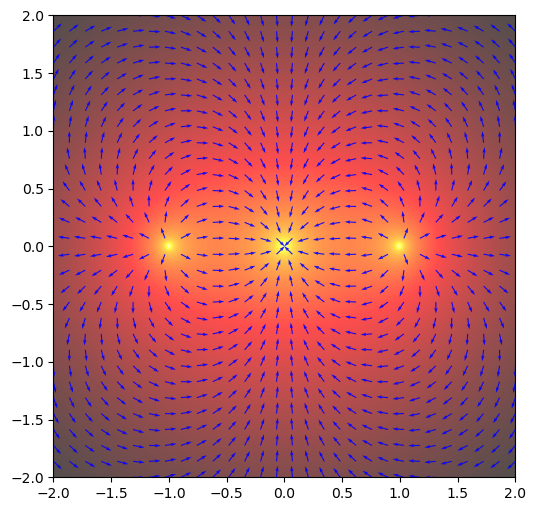

In [210]:
def S(z, sigma=1, interaction=1):
    """Action S(z) = 1/2 * sigma * z^2 + interaction / 4 * z^4"""
    return 1/2 * sigma * z**2 + interaction / 4 * z**4

def S_prime(z, sigma=1, interaction=1):
    """Derivative of the action with respect to z."""
    return sigma * z + interaction * z**3

def S(z, sigma=4j, interaction=1):
    """Action S(z) = 1/2 * sigma * z^2 + interaction / 4 * z^4"""
    return 1/2 * sigma * z**2 + interaction / 4 * z**4

def S_prime(z, sigma=4j, interaction=1):
    """Derivative of the action with respect to z."""
    return sigma * z + interaction * z**3


import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(6, 6), sharex= True, sharey = True)

x_range = (-2, 2)
y_range = (-2, 2)
x = np.linspace(*x_range, 30)
y = np.linspace(*y_range, 30)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

sigma_phi = 3*np.pi
sigma_r = 1
sigma = sigma_r*np.exp(1j*sigma_phi)
lamb = 1

S_values = S_prime(Z, sigma=sigma, interaction=lamb)
U = np.real(S_values)
V = np.imag(S_values)
mags = np.abs(S_values) * 2

crit = np.array([0, np.sqrt(-sigma/lamb), -np.sqrt(-sigma/lamb)])
ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=20, alpha=0.9)
S_prime(crit[0], sigma=sigma, interaction=lamb)


x = np.linspace(*x_range, 500)
y = np.linspace(*y_range, 500)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

S_values = S_prime(Z, sigma=sigma)
mags = np.abs(S_values)
ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

Let's look at the modification 
$$
R(z)
$$

In [4]:
from sympy import symbols, diff, Function, re, im, sqrt, exp
import sympy as sp
sigma_r, lamb_r = symbols('sigma_r, lambda_r', real=True)
sigma_phi, lamb_phi = symbols('sigma_phi, lambda_phi', real=True)
sigma, lamb = sigma_r*exp(sp.I*sigma_phi), lamb_r*exp(sp.I*lamb_phi)
z_phi, z_r = symbols('z_phi, z_r', real=True)
z = z_r*exp(sp.I*z_phi)
z = symbols('z')
# sigma, lamb = symbols('sigma lambda')
action = sigma/2*z**2 + lamb/4*z**4

In [6]:
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = r*(z**2-z_0**2)-exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))
action_mod_func = sp.lambdify((z, z_0, sigma, lamb, r), action_mod, 'numpy')

drift_mod = sp.diff(action_mod, z).simplify()
drift_mod_func  = sp.lambdify((symbols('t z z_0 sigma lambda r')), drift_mod,  'numpy')
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')

In [ ]:
sigma, lamb = symbols("sigma lambda")
sigma_r, lamb_r = symbols('sigma_r, lambda_r', real=True)
sigma_phi, lamb_phi = symbols('sigma_phi, lambda_phi', real=True)
# sigma, lamb = sigma_r*exp(sp.I*sigma_phi), lamb_r*exp(sp.I*lamb_phi)
sp.re(curv_mod.subs({z:0, sigma: sigma_r*exp(sp.I*sigma_phi), lamb: lamb_r*exp(sp.I*lamb_phi)}))    

-sigma_r*sin(sigma_phi)*im(exp(z_0**2*(lambda_r*z_0**2*exp(I*lambda_phi) + 2*sigma_r*exp(I*sigma_phi))/4)/(-r*z_0**2*exp(lambda_r*z_0**4*exp(I*lambda_phi)/4 + sigma_r*z_0**2*exp(I*sigma_phi)/2) + exp(z_0**2*(lambda_r*z_0**2*exp(I*lambda_phi) + 2*sigma_r*exp(I*sigma_phi))/4) - 1)) + (-2*r + sigma_r*cos(sigma_phi))*re(exp(z_0**2*(lambda_r*z_0**2*exp(I*lambda_phi) + 2*sigma_r*exp(I*sigma_phi))/4)/(-r*z_0**2*exp(lambda_r*z_0**4*exp(I*lambda_phi)/4 + sigma_r*z_0**2*exp(I*sigma_phi)/2) + exp(z_0**2*(lambda_r*z_0**2*exp(I*lambda_phi) + 2*sigma_r*exp(I*sigma_phi))/4) - 1))

In [1118]:
def drift_mod_func(z, z0, sigma, lamb, r):
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4
    # overflow = (np.log(r)+np.abs(action) - np.log(np.abs(sigma+lamb*z**2))) > 
    overflow = np.real(action)>100
    if overflow:
        delta_s = action_z_0-action
        out = - 2*r*z*np.exp(action_z_0) / (r*(z**2-z_0**2)*np.exp(action_z_0)-1+np.exp(delta_s))
        # if np.abs(delta_s)
    else:
        numerator = z * (lamb*z**2 - 2*r*np.exp(action) + sigma) * np.exp(action_z_0)
        denominator = np.exp(action+action_z_0) * r * (r*z**2-r*z0**2) - np.exp(action) + np.exp(action_z_0)
        out = numerator / denominator
        # out = 0
    return out

drift_mod_func = np.vectorize(drift_mod_func)

def thimble_flow_equation(t, z, z0, sigma, lamb, r):
    return +np.conj(drift_mod_func(z, z0, sigma, lamb, r))

def anti_thimble_flow_equation(t, z, z0, sigma, lamb, r):
    return -np.conj(drift_mod_func(z, z0, sigma, lamb, r))


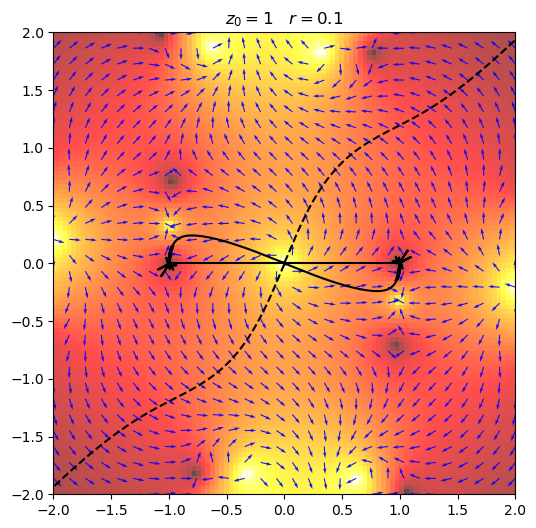

In [1147]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(6, 6), sharex= True, sharey = True)

x_range = (-2, 2)
y_range = (-2, 2)
x = np.linspace(*x_range, 30)
y = np.linspace(*y_range, 30)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

sigma_phi = 3/4*np.pi
sigma_r = 1
sigma = sigma_r*np.exp(1j*sigma_phi)
lamb = 1

r = 0.1
z_0 = 1
# def drift_mod(z, z_0, sigma, lamb, r):

drift_values = drift_mod_func(Z, z_0, sigma, lamb, r)
U = np.real(drift_values)
V = np.imag(drift_values)
mags = np.abs(drift_values) * 2

# crit = np.array([0, np.sqrt(-sigma/lamb), -np.sqrt(-sigma/lamb)])
ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=20, alpha=0.9)

epsilon = 0.01
cp = 0

t_span = (0, 2)  # Integrate from t=0 to t=10
t_eval = np.linspace(t_span[0], t_span[1], 1000)

for perturb in [+epsilon, -epsilon, -1j*epsilon, +1j*epsilon]:
    crit = cp + perturb

    solution = solve_ivp(thimble_flow_equation, t_span, [crit], args=(z_0, sigma, lamb, r), t_eval=t_eval, method="RK45")
    z_values = solution.y[0]
    ax.plot(z_values.real, z_values.imag, color='black')

    solution = solve_ivp(anti_thimble_flow_equation, t_span, [crit], args=(z_0, sigma, lamb, r), t_eval=t_eval, method="RK45")
    z_values = solution.y[0]
    ax.plot(z_values.real, z_values.imag, color='black', ls = '--')

x = np.linspace(*x_range, 100)
y = np.linspace(*y_range, 100)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
S_values = drift_mod_func(Z, z_0, sigma, lamb, r)
mags = np.abs(S_values)
ax.set_title(rf"$z_0 = 1 \quad r=0.1$")
ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

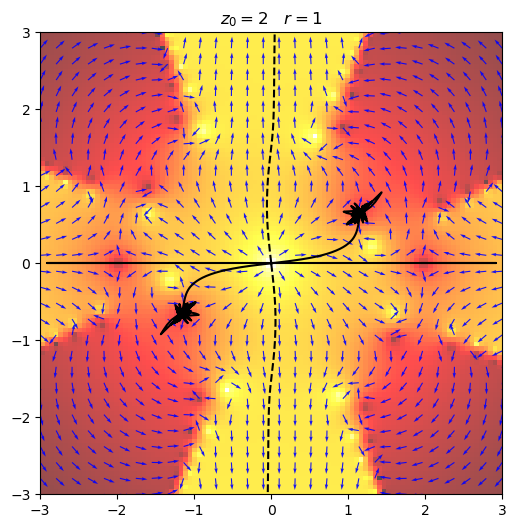

In [1143]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(6, 6), sharex= True, sharey = True)

x_range = (-3, 3)
y_range = (-3, 3)
x = np.linspace(*x_range, 30)
y = np.linspace(*y_range, 30)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

sigma_phi = 3/4*np.pi
sigma_r = 1
sigma = sigma_r*np.exp(1j*sigma_phi)
lamb = 1

r = 1
z_0 = 2
# def drift_mod(z, z_0, sigma, lamb, r):

drift_values = drift_mod_func(Z, z_0, sigma, lamb, r)
U = np.real(drift_values)
V = np.imag(drift_values)
mags = np.abs(drift_values) * 2

# crit = np.array([0, np.sqrt(-sigma/lamb), -np.sqrt(-sigma/lamb)])
ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=20, alpha=0.9)

epsilon = 0.01
cp = 0

t_span = (0, 10)  # Integrate from t=0 to t=10
t_eval = np.linspace(t_span[0], t_span[1], 1000)

for perturb in [+epsilon, -epsilon, -1j*epsilon, +1j*epsilon]:
    crit = cp + perturb

    solution = solve_ivp(thimble_flow_equation, t_span, [crit], args=(z_0, sigma, lamb, r), t_eval=t_eval, method="RK45")
    z_values = solution.y[0]
    ax.plot(z_values.real, z_values.imag, color='black')

    solution = solve_ivp(anti_thimble_flow_equation, t_span, [crit], args=(z_0, sigma, lamb, r), t_eval=t_eval, method="RK45")
    z_values = solution.y[0]
    ax.plot(z_values.real, z_values.imag, color='black', ls = '--')

x = np.linspace(*x_range, 100)
y = np.linspace(*y_range, 100)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
S_values = drift_mod_func(Z, z_0, sigma, lamb, r)
mags = np.abs(S_values)
ax.set_title(rf"$z_0 = 2 \quad r=1$")

ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

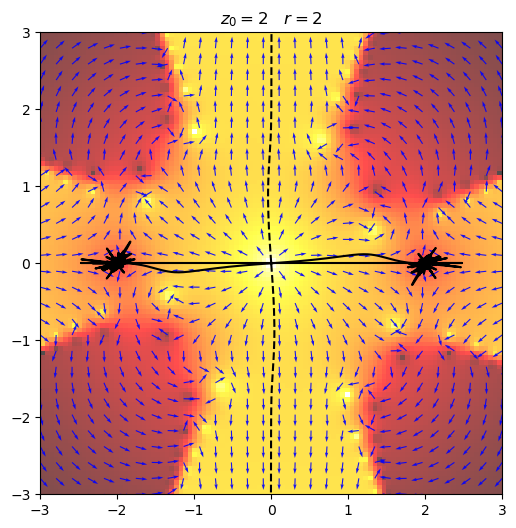

In [1144]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(6, 6), sharex= True, sharey = True)

x_range = (-3, 3)
y_range = (-3, 3)
x = np.linspace(*x_range, 30)
y = np.linspace(*y_range, 30)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

sigma_phi = 3/4*np.pi
sigma_r = 1
sigma = sigma_r*np.exp(1j*sigma_phi)
lamb = 1

r = 2
z_0 = 2
# def drift_mod(z, z_0, sigma, lamb, r):

drift_values = drift_mod_func(Z, z_0, sigma, lamb, r)
U = np.real(drift_values)
V = np.imag(drift_values)
mags = np.abs(drift_values) * 2

# crit = np.array([0, np.sqrt(-sigma/lamb), -np.sqrt(-sigma/lamb)])
ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=20, alpha=0.9)

epsilon = 0.01
cp = 0

t_span = (0, 30)  # Integrate from t=0 to t=10
t_eval = np.linspace(t_span[0], t_span[1], 1000)

for perturb in [+epsilon, -epsilon, -1j*epsilon, +1j*epsilon]:
    crit = cp + perturb

    solution = solve_ivp(thimble_flow_equation, t_span, [crit], args=(z_0, sigma, lamb, r), t_eval=t_eval, method="RK45")
    z_values = solution.y[0]
    ax.plot(z_values.real, z_values.imag, color='black')

    solution = solve_ivp(anti_thimble_flow_equation, t_span, [crit], args=(z_0, sigma, lamb, r), t_eval=t_eval, method="RK45")
    z_values = solution.y[0]
    ax.plot(z_values.real, z_values.imag, color='black', ls = '--')

x = np.linspace(*x_range, 100)
y = np.linspace(*y_range, 100)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
S_values = drift_mod_func(Z, z_0, sigma, lamb, r)
mags = np.abs(S_values)
ax.set_title(rf"$z_0 = 2 \quad r=2$")

ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

In [108]:
# basic parameters
from sympy import symbols
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

In [109]:
import sympy as sp
# action
action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

# drift
drift = sp.diff(action, z)

# curvature
curv = sp.diff(drift, z)

# density
density = sp.exp(-action)

In [110]:
# lambdify these
action_func = sp.lambdify((z, sigma, lamb), action, 'numpy')
drift_func = sp.lambdify((z, sigma, lamb), drift, 'numpy')
curv_func = sp.lambdify((z, sigma, lamb), curv, 'numpy')

In [111]:
from sympy import exp
# Modification
mod = r*(z**2-z_0**2)-exp(-action_z_0)

In [112]:
# modified action
action_mod = action-sp.log(1+mod*exp(action))

# modified drift
drift_mod = (sp.diff(action_mod, z)).simplify()

# modified curvature
curv_mod = (sp.diff(drift_mod, z)).simplify()

# modified density
density_mod = (sp.exp(-action_mod)).simplify()
drift_mod

z*(lambda*z**2 - 2*r*exp(lambda*z**4/4 + sigma*z**2/2) + sigma)*exp(lambda*z_0**4/4 + sigma*z_0**2/2)/(r*z**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - r*z_0**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - exp(lambda*z**4/4 + sigma*z**2/2) + exp(lambda*z_0**4/4 + sigma*z_0**2/2))

In [113]:
# lambdify these
action_mod_func = sp.lambdify((z, sigma, lamb, z_0, r), action_mod, 'numpy')
drift_mod_func = sp.lambdify((z, sigma, lamb, z_0, r), drift_mod, 'numpy')
curv_mod_func = sp.lambdify((z, sigma, lamb, z_0, r), curv_mod, 'numpy')

In [249]:
z = 10
sigma, lamb, z_0, r = 1, 1, 1, 1


action = action_func(z, sigma, lamb)
action_z0 = action_func(z_0, sigma, lamb)

gamma = 35
if z**2 == z_0**2:    
    if np.real(action-action_z0) < gamma:
        psi = -np.log(1-np.exp(action-action_z0))
    else: 
        psi = -(action-action_z0+1j*np.pi)


(-2549.25-3.141592653589793j)

In [114]:
import numpy as np

def action_mod(z, sigma, lamb, z_0, r):
    action = action_func(z, sigma, lamb)
    action_z0 = action_func(z_0, sigma, lamb)

    action_z0_abs = np.abs(action_z0)

    mod = r*(z**2-z_0**2)

    if np.mod(mod) == 0:
        val_under_log = 1-np.exp(action-action_z0)

    if action_z0_abs > 23:
        mod = r*(z**2-z_0**2)
        # ignore term np.exp(-action_z0) < 1e-20
    else: 
        mod = r*(z**2-z_0**2) - np.exp(-action_z0)

    if np.abs(action+np.log(mod)) > 23:
        # ignore plus one in 1 + mod*np.exp(action)
        out = action - np.log(mod) - action
    else: 
        out = action -np.log(1 + mod*np.exp(action))
    return out

action_mod = np.vectorize(action_mod)

In [135]:
def drift_mod_func(z, sigma, lamb, z_0, r):
    action = action_func(z, sigma, lamb)
    action_z0 = action_func(z_0, sigma, lamb)
    drift = drift_func(z, sigma, lamb)+0j

    if action+np.log(2*r*(z+0j)) > 23 and np.log(drift+0j) < 13:
        # numerator = np.exp(action_z0) * (-2*r*z) 
        # denominator = (np.exp(action_z0)*r*(z**2-z_0**2) - 1 + np.exp(action_z0-action) )
        if np.real(action)>0:
            numerator = (-2*r*z) 
            denominator = r*(z**2-z_0**2) - np.exp(-action_z0) + np.exp(-action)
        else:
            numerator = (-2*r*z) * np.exp(action)
            denominator = r*(z**2-z_0**2)*np.exp(action) - np.exp(-action_z0+action) + 1
    else: 
      
        if np.real(action)>0:
            numerator = drift*np.exp(-action)-2*r*z
            denominator = r*(z**2-z_0**2) - np.exp(-action_z0)+ np.exp(-action)
        else: 
            numerator = np.exp(np.log(drift))-2*r*z*np.exp(action)
            denominator = np.exp(action)*r*(z**2-z_0**2) - np.exp(action-action_z0)+ 1
    
    return numerator/ denominator
drift_mod_func = np.vectorize(drift_mod_func)

In [136]:
def thimble_flow_equation(t, z, sigma, lamb, z_0, r):
    return +np.conj(drift_mod_func(z, sigma, lamb, z_0, r))

def anti_thimble_flow_equation(t, z, sigma, lamb, z_0, r):
    return -np.conj(drift_mod_func(z, sigma, lamb, z_0, r))


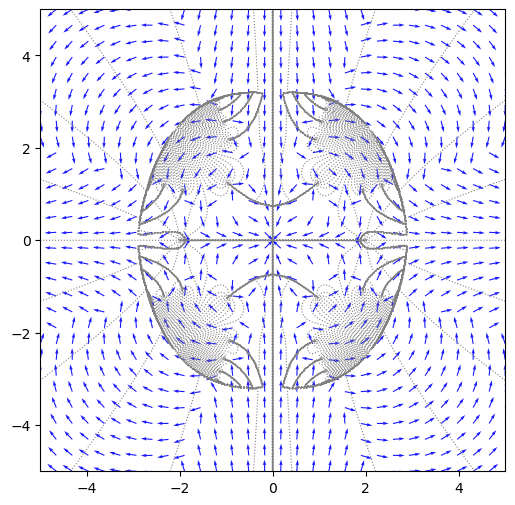

In [169]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

fig, ax = plt.subplots(1, figsize=(6, 6), sharex= True, sharey = True)

x_range = (-5, 5)
y_range = (-5, 5)
x = np.linspace(*x_range, 30)
y = np.linspace(*y_range, 30)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

sigma_phi = 0
sigma_r = 1
sigma = sigma_r*np.exp(1j*sigma_phi)
lamb = 1

r = 1
z_0 = 2
# def drift_mod(z, z_0, sigma, lamb, r):

drift_values = -drift_mod_func(Z, sigma, lamb, z_0, r)
U = np.real(drift_values)
V = np.imag(drift_values)
mags = np.abs(drift_values) * 2

crit = np.array([0, np.sqrt(-sigma/lamb), -np.sqrt(-sigma/lamb)])
ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=20, alpha=0.9)

epsilon = 0.1
cp = 0

t_span = (0, 100)  # Integrate from t=0 to t=10
t_eval = np.linspace(t_span[0], t_span[1], 100)

# for perturb in [(1+0j)*epsilon, (1+1j)*epsilon, (0+1j)*epsilon, (-1+1j)*epsilon, (-1+0j)*epsilon, (-1-1j)*epsilon, (0-1j)*epsilon, (1-1j)*epsilon]:
#     crit = cp + perturb

#     solution = solve_ivp(thimble_flow_equation, t_span, [crit], args=(sigma, lamb, z_0, r), t_eval=t_eval, method="RK45")
#     z_values = solution.y[0]
#     ax.plot(z_values.real, z_values.imag, color='black', ls = '-' )

#     solution = solve_ivp(anti_thimble_flow_equation, t_span, [crit], args=(z_0, sigma, lamb, r), t_eval=t_eval, method="RK45")
#     z_values = solution.y[0]
#     ax.plot(z_values.real, z_values.imag, color='black', ls = '--')

x = np.linspace(*x_range, 500)
y = np.linspace(*y_range, 500)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# drift_values = -drift_mod_func(Z, sigma, lamb, z_0, r)
# mags = np.abs(drift_values)
# ax.set_title(rf"$z_0 = 1 \quad r=0.1$")
# ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

ax.set_xlim(*x_range)
ax.set_ylim(*y_range)

S_values = action_mod(Z, sigma, lamb, z_0, r)
contours = ax.contour(X, Y, np.imag(S_values), levels=100, colors='gray', linestyles='dotted', linewidths=0.8)